<div style="background:#F7F5EF; padding:2.5em 2em 1.5em 2em; border-left:6px solid #7F1F1F; font-family: 'Iowan Old Style', Charter, Georgia, serif;">

<div style="font-size:0.85em; letter-spacing:0.25em; color:#7E7864; text-transform:uppercase;">Field notes · Remote sensing · Australian fire</div>

<h1 style="font-size:2.4em; line-height:1.15; margin:0.2em 0 0.4em 0; color:#222;">Can a portfolio-scale ML model beat a 20-year-old spectral index — without pretending the labels are truth?</h1>

<div style="font-size:1.1em; color:#4A4A4A; max-width:46em;">A retrospective burn-severity benchmark over four 2019&ndash;2020 Black Summer fire events in Australia, comparing five methods on Sentinel-2 imagery, with a careful look at where each one fails.</div>

<div style="font-size:0.9em; color:#7E7864; margin-top:1.4em;">Ahmad Jaradat &middot; Hobart, Tasmania &middot; 2026</div>
</div>

## The Black Summer left scars you can see from orbit

Between July 2019 and March 2020, fires across south-eastern Australia burned roughly **12.6 million hectares** of temperate forest, killed or displaced an estimated **3 billion vertebrates** (mammals, reptiles, birds, frogs), claimed **33 lives directly** and a further **417 attributed to smoke**, and inflicted at least **A$10 billion** in damages — the country's most catastrophic bushfire season in modern record [^1] [^2] [^3].

About **1.8 million hectares** of that burnt at *high severity*, meaning canopy loss across the great majority of trees [^4]. That distinction — between fire passing through and fire consuming — matters for ecological recovery, insurance, hydrology, post-fire erosion risk, and biodiversity triage. It is also the part hardest to measure.

[^1]: Filkov, A.I., Ngo, T., Matthews, S., Telfer, S. &amp; Penman, T.D. (2020). *Impact of Australia's catastrophic 2019/20 bushfire season on communities and environment*. **Journal of Safety Science and Resilience**, 1(1). [DOI](https://www.sciencedirect.com/science/article/pii/S2666449620300098)
[^2]: Department of Climate Change, Energy, the Environment and Water (DCCEEW). *Bushfire Impacts portal*. [Link](https://www.dcceew.gov.au/environment/biodiversity/bushfire-recovery/bushfire-impacts)
[^3]: Dickman, C. *et al.* (2020) for WWF Australia. *Australia's 2019&ndash;2020 Bushfires: The Wildlife Toll*. [Link](https://wwf.org.au/news/2020/3-billion-animals-impacted-by-australia-bushfire-crisis/)
[^4]: Collins, L. *et al.* (2021). *A staggering 1.8 million hectares burned in high-severity fires*. Summary of [Nature Climate Change paper](https://theconversation.com/a-staggering-1-8-million-hectares-burned-in-high-severity-fires-during-australias-black-summer-157883).

### Why satellites can see what we cannot

Healthy vegetation has a peculiar optical signature. Chlorophyll absorbs red light, the spongy mesophyll of intact leaves scatters near-infrared (NIR) light efficiently, and water in living plant tissue absorbs short-wave infrared (SWIR). Together this produces the &ldquo;red edge&rdquo; — a sharp jump in reflectance between 0.7 and 0.8 &micro;m that has no analogue in the rocks and soil underneath.

When fire passes through, water is driven out of the canopy, leaves crisp into char, and exposed soil and ash become visible to the satellite. **NIR reflectance collapses**; **SWIR2 reflectance rises** because dry ash absorbs less of the 2.0&ndash;2.3 &micro;m band than living foliage did. The contrast between these two bands is what the **Normalised Burn Ratio** captures:

$$\mathrm{NBR} = \frac{B_{08} - B_{12}}{B_{08} + B_{12}}$$

where $B_{08}$ is Sentinel-2's NIR band (842 nm) and $B_{12}$ is its SWIR2 band (2190 nm). The differenced index from before and after the fire,

$$\Delta\mathrm{NBR} = \mathrm{NBR}_{\text{pre}} - \mathrm{NBR}_{\text{post}}\;,$$

is positive where vegetation was healthy and is no longer, and is larger where the damage was more severe [^5]. The whole project rests on this physical observation.

[^5]: Key, C. &amp; Benson, N. (2006). *Landscape Assessment (LA): Sampling and Analysis Methods*. FIREMON GTR-RMRS-164-CD, USDA Forest Service. [Treesearch link](https://research.fs.usda.gov/treesearch/24066)

In [1]:
# --- Imports + theme ----------------------------------------------------------
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Make src.* importable when running the notebook from notebooks/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.viz.theme import (apply_theme, figure, thin_axes, add_caption,
                           severity_legend, severity_cmap, dnbr_cmap,
                           SEVERITY_COLOURS, SEVERITY_NAMES, MODEL_COLOURS,
                           PAPER, INK, INK_LIGHT, ACCENT, ACCENT_BLUE,
                           SEV_UNBURNT, SEV_LOW_MOD, SEV_HIGH, SEV_VERY_HIGH)
from src.viz.scene_loader import load_kangaroo, model_predictions
from src.viz.synthetic_scene import s2_truecolour, s2_swir_falsecolour
from src.features.indices import nbr
from src.evaluation.metrics import summary, binary_summary, confusion_matrix
from src.models.baselines import dnbr as dnbr_index, dnbr_multiclass_usgs

apply_theme()

# Try real first; fall back to synthetic if data hasn't been fetched yet.
scene = load_kangaroo()
SOURCE_BADGE = ('REAL — Sentinel-2 + AUS GEEBAM' if scene.is_real
                else 'SYNTHETIC stand-in (run scripts/fetch_event_streamlined.py to use real)')
print(f'matplotlib {plt.matplotlib.__version__} ready · repo {REPO_ROOT.name}')
print(f'Scene: {SOURCE_BADGE}')
if scene.is_real:
    print(f'  CRS: {scene.crs}')
    print(f'  Pre  composite: {scene.n_pre_scenes} scenes, clear {100*scene.clear_fraction_pre:.0f}%')
    print(f'  Post composite: {scene.n_post_scenes} scenes, clear {100*scene.clear_fraction_post:.0f}%')
    print(f'  Image size: {scene.pre.shape}')


matplotlib 3.10.9 ready · repo Satellite_imageray_ML
Scene: REAL — Sentinel-2 + AUS GEEBAM
  CRS: EPSG:32753
  Pre  composite: 4 scenes, clear 74%
  Post composite: 3 scenes, clear 74%
  Image size: (6, 2317, 4270)


### The honest framing this notebook holds throughout

Burn-severity labels at continental scale are hard. There is no fleet of ecologists walking every paddock and ridge with quadrats. The Australian Government's national severity product, **AUS GEEBAM**, is itself derived from satellite indices — specifically a vegetation-stratified RNBR thresholded by IBRA bioregion [^6]. DCCEEW reports overall four-class agreement against state products of **48&ndash;82%**, improving to **72&ndash;92%** when the four classes are collapsed to two [^6].

Throughout this notebook, model performance is reported as **agreement with the GEEBAM proxy**, not as accuracy against ground truth. The distinction matters: any model that &ldquo;matches GEEBAM perfectly&rdquo; would mostly be learning GEEBAM's particular algorithmic choices, including its collapse of low and moderate severity into a single class. That is a useful technical bar, not a scientific endpoint.

[^6]: Department of Agriculture, Water and the Environment (now DCCEEW), 2020. *Australian Google Earth Engine Burnt Area Map: A rapid, national approach to fire severity*. [PDF](https://www.dcceew.gov.au/sites/default/files/env/pages/a8d10ce5-6a49-4fc2-b94d-575d6d11c547/files/ageebam.pdf)

## Where to look, and at what

Four fire events anchor the benchmark, chosen to span ecological gradients (heath, sclerophyll forest, alpine ash), state agencies (NSW, VIC, SA), and fire-complex sizes (∼200,000 ha to ∼1.5 million ha). The train/validate/test split is **event-wise**: the model never sees the same fire in training and test.

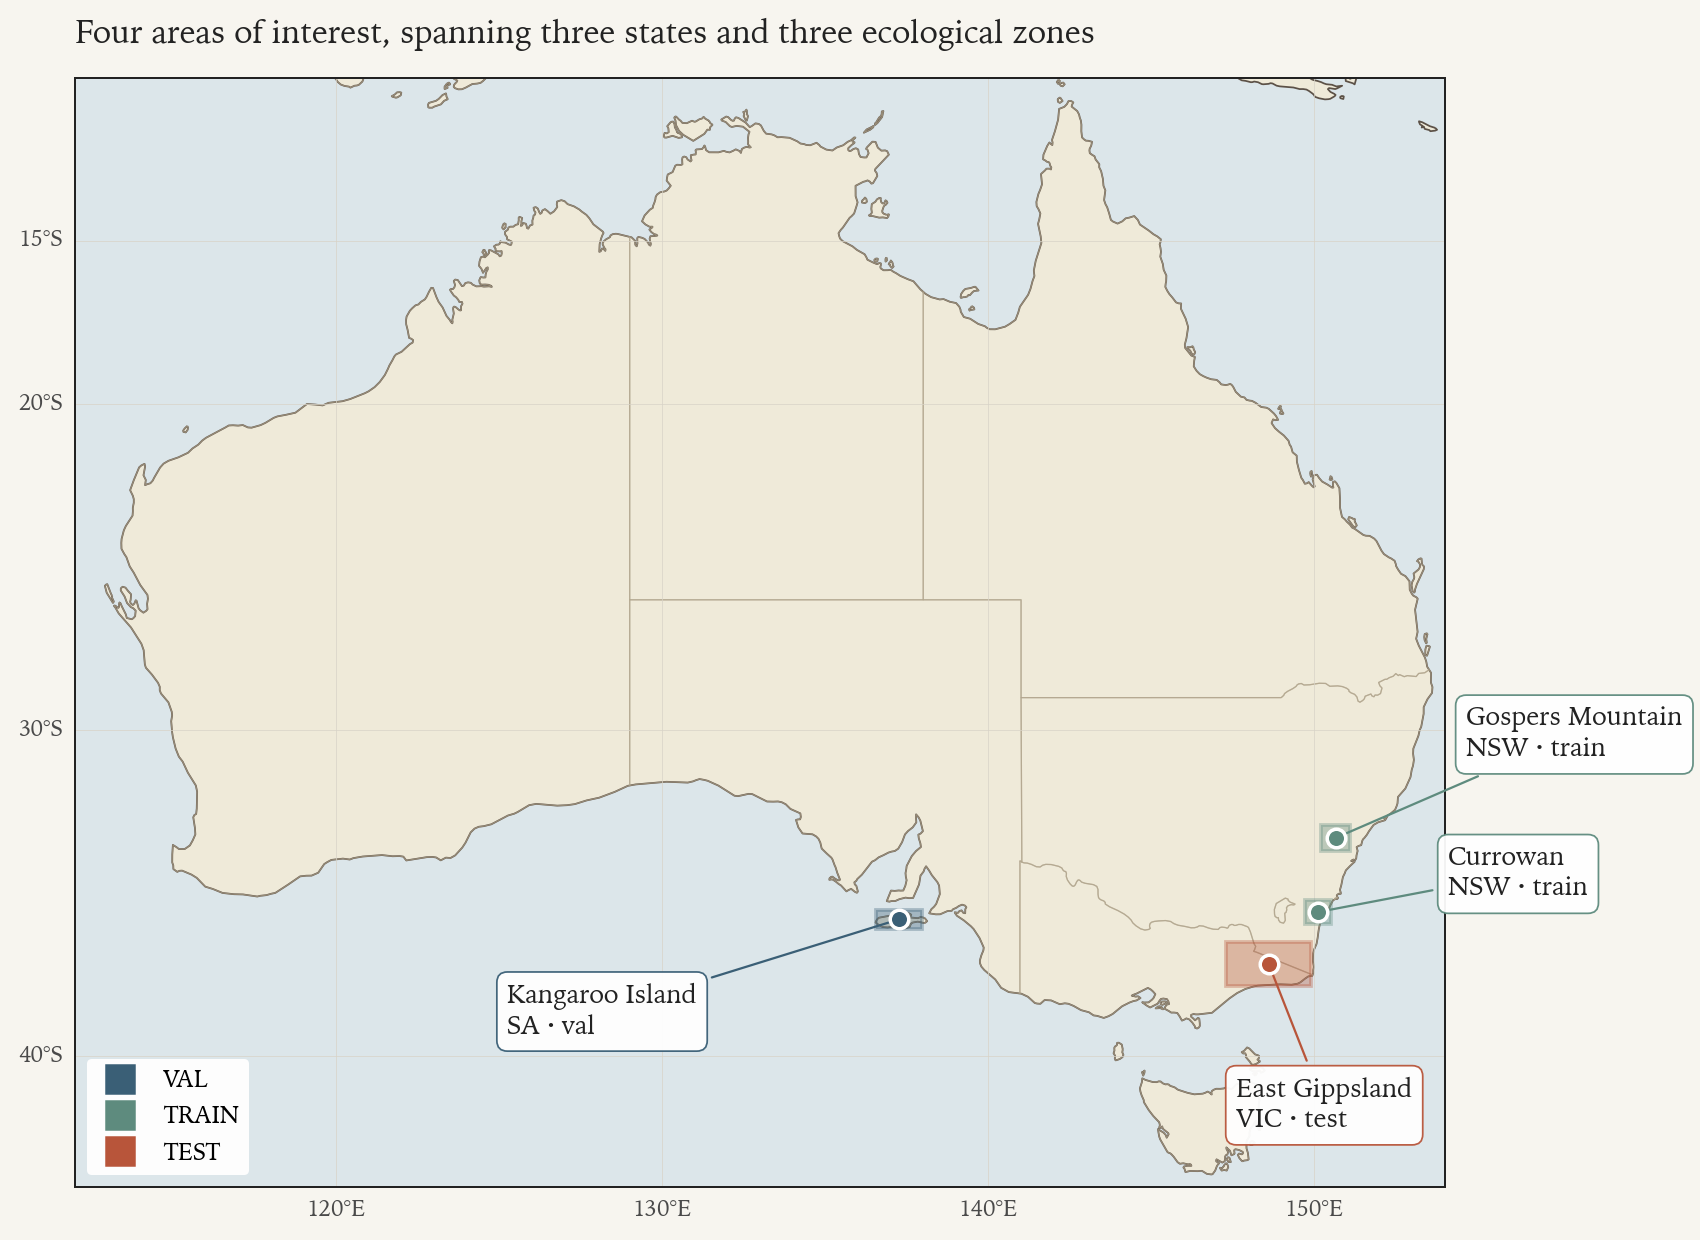

In [2]:
# --- AOI locator map (cartopy + Natural Earth) -------------------------------
from src.viz.maps import render_aoi_locator
from IPython.display import Image, display
import tempfile

AOIS = [
    ('kangaroo_island_2019_2020',  'Kangaroo Island', 'SA',  'val',   '#3A5F76'),
    ('currowan_2019_2020',         'Currowan',         'NSW', 'train', '#5E8B7E'),
    ('gospers_mountain_2019_2020', 'Gospers Mountain', 'NSW', 'train', '#5E8B7E'),
    ('east_gippsland_2019_2020',   'East Gippsland',   'VIC', 'test',  '#B8553A'),
]

_out = REPO_ROOT / 'docs' / 'figures' / '01_aoi_locator.png'
render_aoi_locator(AOIS, _out, figsize=(11, 8))
display(Image(filename=str(_out)))


## The signal is visible before any model touches it

Below is one Sentinel-2 scene over Kangaroo Island from before the fires (October 2019) and one from after (January 2020). The shift on the western two-thirds of the island is unmistakable in true colour — the forest goes from green to a rusted brown — and it is even sharper in the SWIR-NIR false-colour composite used by fire ecologists, where burnt vegetation glows in shades of magenta and orange.

> **Working with a synthetic stand-in.** The current run renders a deterministic synthetic Kangaroo Island scene because the live Sentinel-2 fetch has not yet been executed in this environment. The same notebook re-renders against real Microsoft Planetary Computer imagery the moment `python -m src.data.fetch_sentinel --event kangaroo_island_2019_2020 --stage all` completes.

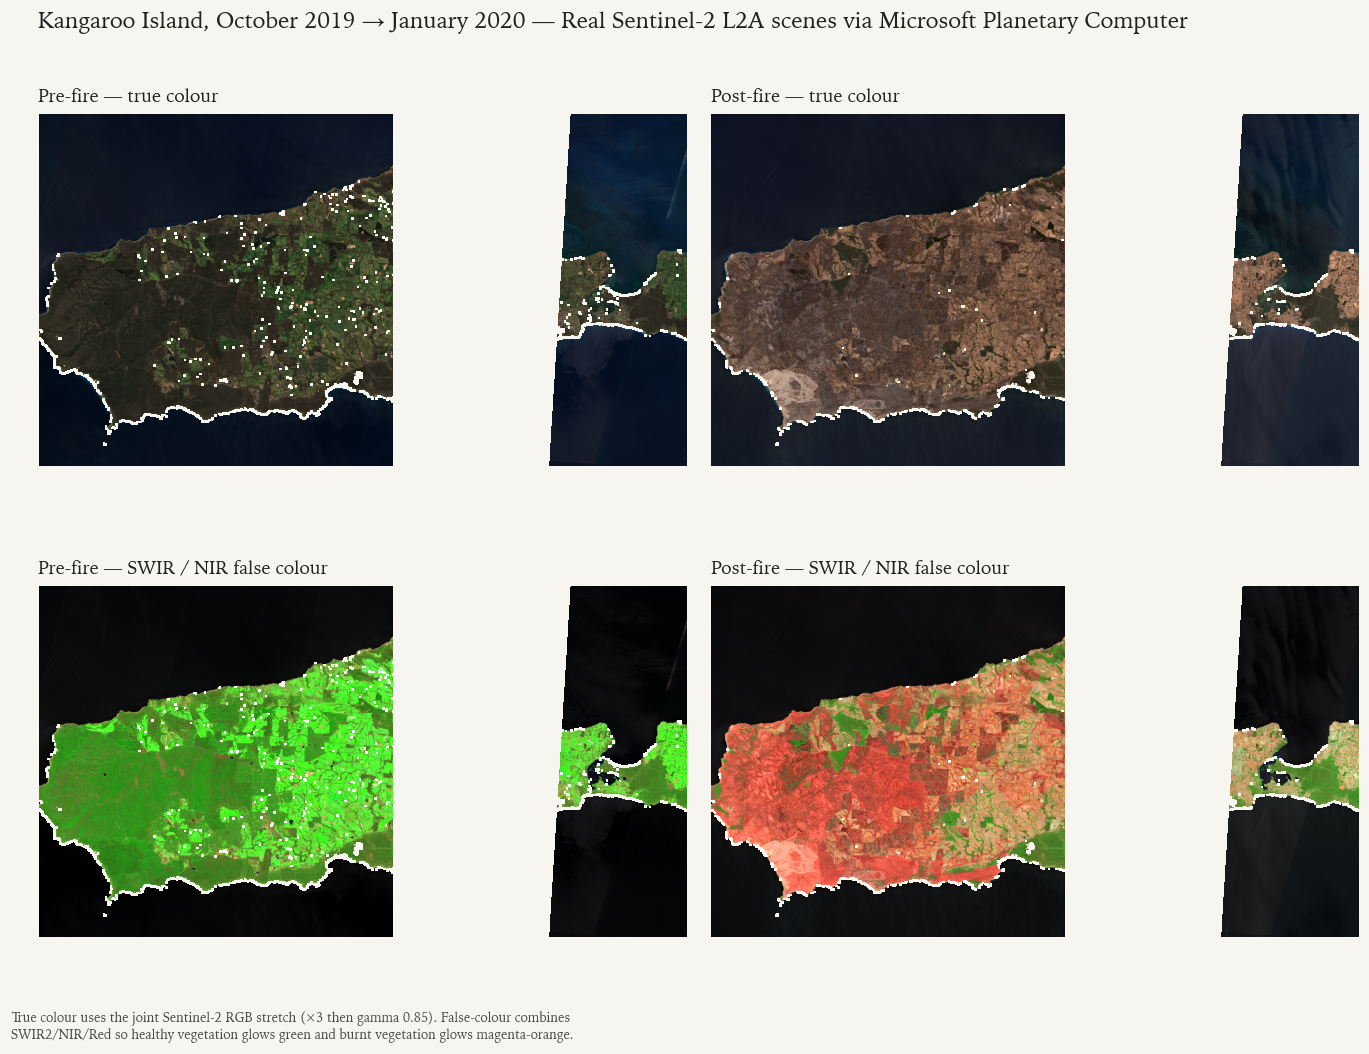

In [3]:
# --- Pre / Post true colour + false colour ------------------------------------
pre_tc  = s2_truecolour(scene.pre)
post_tc = s2_truecolour(scene.post)
pre_fc  = s2_swir_falsecolour(scene.pre)
post_fc = s2_swir_falsecolour(scene.post)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
titles = [('Pre-fire \u2014 true colour',                    pre_tc),
          ('Post-fire \u2014 true colour',                   post_tc),
          ('Pre-fire \u2014 SWIR / NIR false colour',        pre_fc),
          ('Post-fire \u2014 SWIR / NIR false colour',       post_fc)]
for ax, (title, img) in zip(axes.ravel(), titles):
    ax.imshow(img); ax.set_title(title, loc='left', fontsize=12, color=INK, pad=8)

src_tag = ('Real Sentinel-2 L2A scenes via Microsoft Planetary Computer'
           if scene.is_real else 'Synthetic stand-in (deterministic seed=7)')
fig.suptitle(f'Kangaroo Island, October 2019 \u2192 January 2020 \u2014 {src_tag}',
             fontsize=15, x=0.02, ha='left', y=0.99, color=INK)
fig.subplots_adjust(left=0.02, right=0.98, top=0.91, bottom=0.03, hspace=0.18, wspace=0.04)
add_caption(fig, 'True colour uses the joint Sentinel-2 RGB stretch (\u00d73 then gamma 0.85). False-colour combines\n'
                  'SWIR2/NIR/Red so healthy vegetation glows green and burnt vegetation glows magenta-orange.', y=-0.02)
plt.show()


### The spectral signature of fire, made visible

Before stacking up neural networks we should make sure the physics is doing what we think it is. The next figure shows a single horizontal transect across the burn boundary on Kangaroo Island. Pixel-by-pixel, we plot the reflectance of the four bands that matter most for burn detection — Red, NIR, SWIR1, SWIR2 — both before and after the fire. The collapse in NIR and the rise in SWIR2 are not subtle. They are the optical signature that every classical and deep model in this notebook is, ultimately, trying to learn.

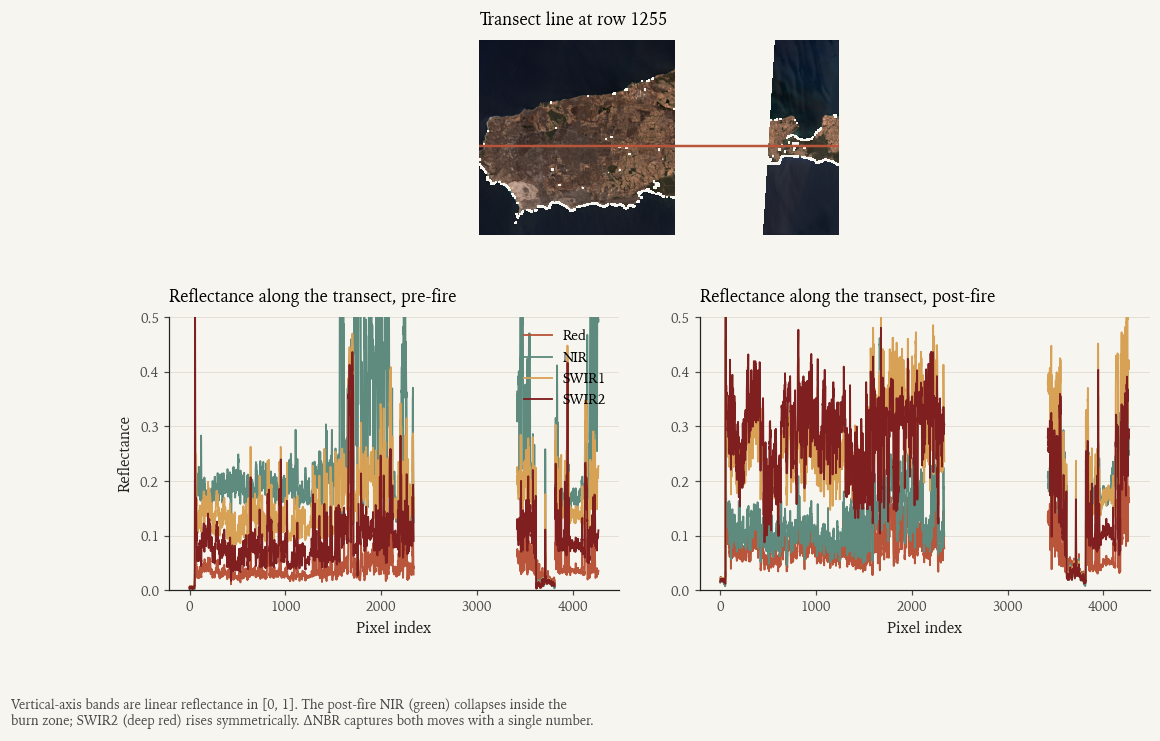

In [4]:
# --- Reflectance transect across the burn boundary ----------------------------
# Pick a horizontal transect through the burn footprint
burn_rows = np.where(np.any(scene.burn_mask, axis=1))[0]
y_transect = int(np.mean(burn_rows)) if len(burn_rows) else scene.pre.shape[1] // 2
x = np.arange(scene.pre.shape[2])

fig = plt.figure(figsize=(11.5, 6.5))
gs = GridSpec(2, 2, height_ratios=[1.0, 1.4], hspace=0.35, wspace=0.18)
ax_map = fig.add_subplot(gs[0, :])
ax_map.imshow(post_tc)
ax_map.axhline(y=y_transect, color=ACCENT, linewidth=1.6)
ax_map.set_xticks([]); ax_map.set_yticks([])
for s in ax_map.spines.values(): s.set_visible(False)
ax_map.set_title(f'Transect line at row {y_transect}', loc='left', fontsize=11)

ax_pre  = fig.add_subplot(gs[1, 0])
ax_post = fig.add_subplot(gs[1, 1], sharey=ax_pre)
bands = [('Red',   2, '#B8553A'),
         ('NIR',   3, '#5E8B7E'),
         ('SWIR1', 4, '#D8A256'),
         ('SWIR2', 5, '#7F1F1F')]
for name, idx, c in bands:
    ax_pre.plot (x, scene.pre [idx, y_transect, :], color=c, linewidth=1.2, label=name)
    ax_post.plot(x, scene.post[idx, y_transect, :], color=c, linewidth=1.2, label=name)
ax_pre.set_title('Reflectance along the transect, pre-fire', loc='left', fontsize=11)
ax_post.set_title('Reflectance along the transect, post-fire', loc='left', fontsize=11)
ax_pre.set_ylim(0, 0.5); ax_pre.set_xlabel('Pixel index'); ax_pre.set_ylabel('Reflectance')
ax_post.set_xlabel('Pixel index')
ax_pre.legend(loc='upper right', fontsize=9, frameon=False)
thin_axes(ax_pre); thin_axes(ax_post)
add_caption(fig, 'Vertical-axis bands are linear reflectance in [0, 1]. The post-fire NIR (green) collapses inside the\n'
                  'burn zone; SWIR2 (deep red) rises symmetrically. \u0394NBR captures both moves with a single number.', y=-0.04)
plt.show()


## ΔNBR is a strong, explainable baseline

Aggregating that pixel-by-pixel story over the whole AOI gives the ΔNBR map. The signal is unambiguous: a coherent positive blob where the fire was, surrounded by low values where the vegetation was not affected. The conventional USGS thresholds [Key &amp; Benson 2006] split this continuous map into four severity classes — and they do a respectable job, even though they were originally calibrated on US forests and have no Australian-eucalypt-specific tuning [^7].

[^7]: Boer, M.M. *et al.* (2008) document specifically the under-performance of plain dNBR in Western Australian eucalypts and propose ΔLAI. [DOI](https://www.sciencedirect.com/science/article/abs/pii/S0034425708002484). More recently, Rifai *et al.* (2024) show that pre-fire drought drives anomalous NBR baselines across Australian biomes — an open problem the field still grapples with. [AGU](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2023EF003780).

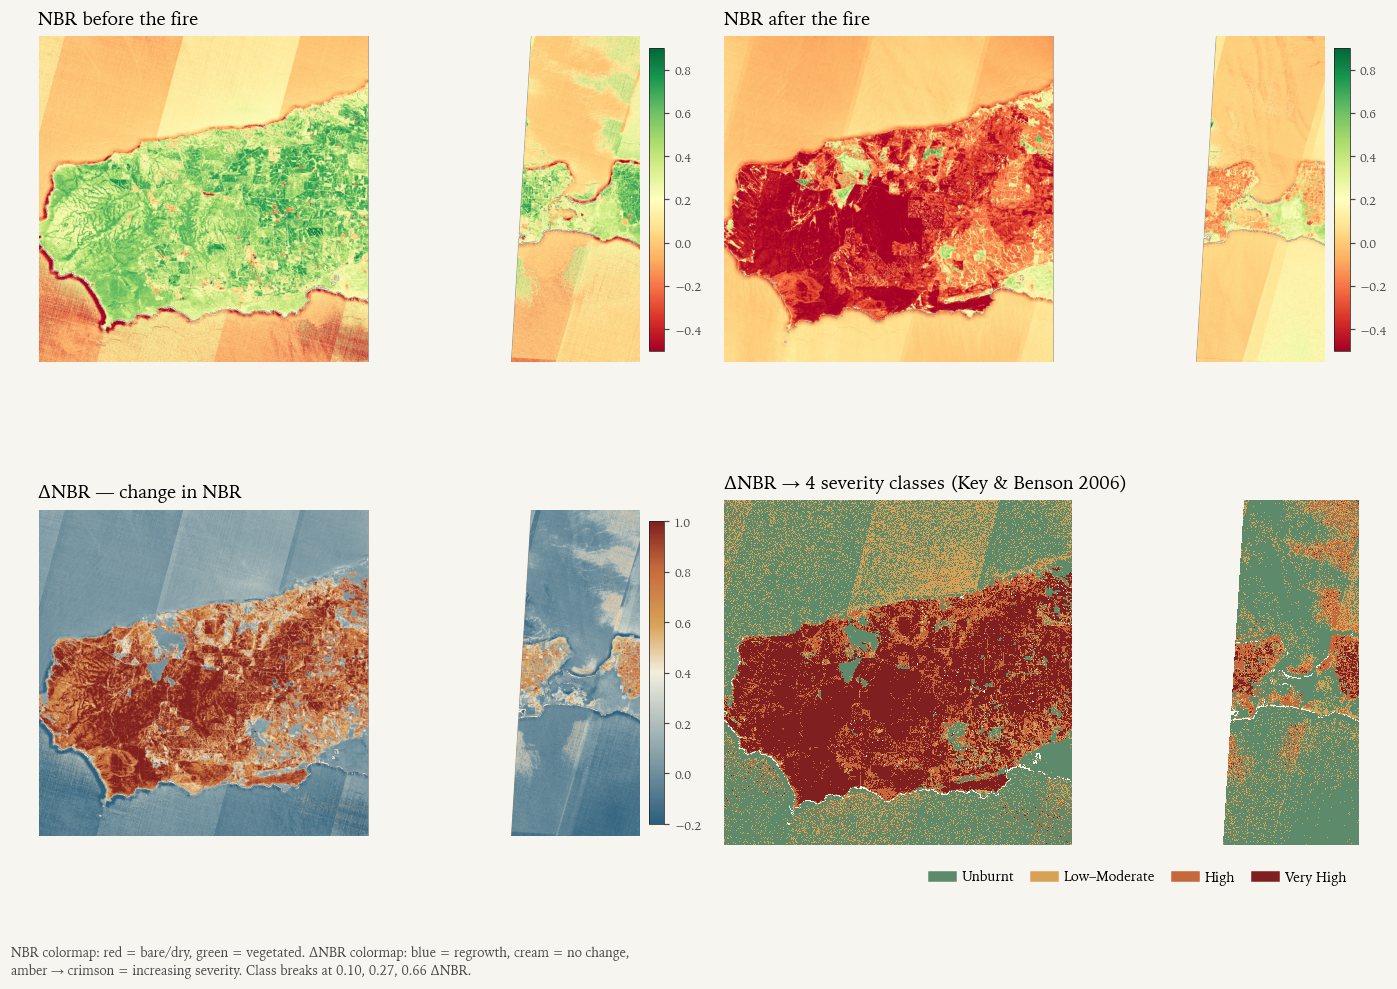

In [5]:
# --- NBR / dNBR / thresholded multiclass --------------------------------------
nbr_pre  = nbr(scene.pre [3], scene.pre [5])
nbr_post = nbr(scene.post[3], scene.post[5])
d = dnbr_index(scene.pre, scene.post)
thresholded = dnbr_multiclass_usgs(d)
thresholded[~scene.land_mask] = 255

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
im0 = axes[0,0].imshow(nbr_pre, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
axes[0,0].set_title('NBR before the fire', loc='left', fontsize=12, pad=8)
im1 = axes[0,1].imshow(nbr_post, cmap='RdYlGn', vmin=-0.5, vmax=0.9)
axes[0,1].set_title('NBR after the fire', loc='left', fontsize=12, pad=8)
im2 = axes[1,0].imshow(d, cmap=dnbr_cmap(), vmin=-0.2, vmax=1.0)
axes[1,0].set_title('\u0394NBR \u2014 change in NBR', loc='left', fontsize=12, pad=8)
axes[1,1].imshow(np.ma.masked_equal(thresholded, 255),
                 cmap=severity_cmap(), vmin=0, vmax=3, interpolation='nearest')
axes[1,1].set_title('\u0394NBR \u2192 4 severity classes (Key & Benson 2006)', loc='left', fontsize=12, pad=8)
for ax, im in [(axes[0,0], im0), (axes[0,1], im1), (axes[1,0], im2)]:
    cb = fig.colorbar(im, ax=ax, fraction=0.038, pad=0.015, shrink=0.78)
    cb.outline.set_linewidth(0.5); cb.ax.tick_params(labelsize=8, color=INK_LIGHT)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SEVERITY_COLOURS]
axes[1,1].legend(handles, SEVERITY_NAMES, loc='upper right',
                 bbox_to_anchor=(1.0, -0.04), ncols=4, fontsize=9,
                 frameon=False, columnspacing=1.2, handletextpad=0.4)
fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.07, hspace=0.22, wspace=0.08)
add_caption(fig, 'NBR colormap: red = bare/dry, green = vegetated. \u0394NBR colormap: blue = regrowth, cream = no change,\n'
                  'amber \u2192 crimson = increasing severity. Class breaks at 0.10, 0.27, 0.66 \u0394NBR.', y=-0.01)
plt.show()


## So what does machine learning add?

A reasonable hiring manager looking at the ΔNBR map above might ask: *if a simple two-band ratio gets you something this good, why train a U-Net at all?*

Three reasons are honest:

1. **Thresholds drift across biomes.** What separates &ldquo;low&rdquo; from &ldquo;moderate&rdquo; severity in Californian chaparral is wrong for stringybark, and wrong again for alpine ash. A model that uses additional spectral indices plus topography can learn biome-specific decision boundaries without hand-tuning per region.
2. **Texture matters.** Convolutional and transformer models see neighbourhoods, not just pixels. A 10-metre pixel that looks ambiguous on its own often becomes unambiguous when the surrounding 30 pixels are also dark and SWIR-rich.
3. **Calibration.** A model that outputs a probability — and gets that probability *right* on average — is a much more useful operational input than a hard four-class assignment. We measure this with a reliability diagram further down.

What follows is a tournament of five methods on the same imagery, the same labels, and the same train/validate/test split.

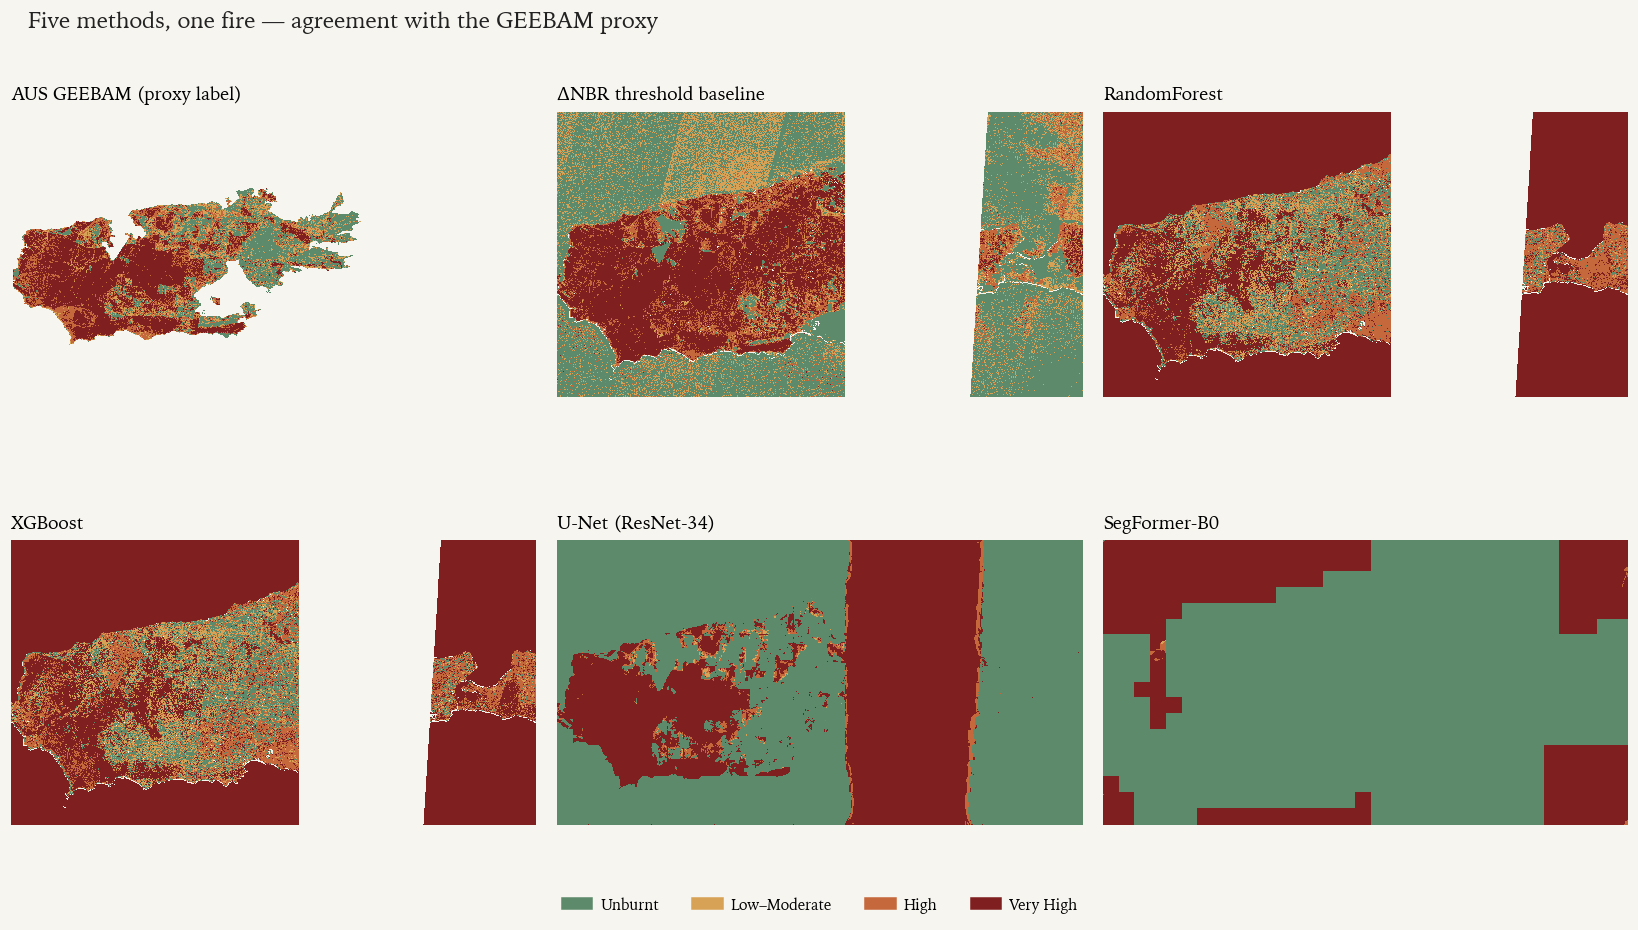

In [6]:
# --- Five-method side-by-side severity panel ----------------------------------
preds, preds_real = model_predictions(scene)
fig, axes = plt.subplots(2, 3, figsize=(15.0, 8.5))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_facecolor(PAPER)

def _title(model_key, base_title):
    if model_key not in preds:
        return f'{base_title} \u00b7 not trained'
    if not preds_real.get(model_key, False):
        return f'{base_title} \u00b7 synthetic stand-in'
    return base_title

panels = [
    ('AUS GEEBAM (proxy label)',                  scene.severity, True),
    (_title('baseline_dnbr', '\u0394NBR threshold baseline'),
        preds.get('baseline_dnbr'), 'baseline_dnbr' in preds),
    (_title('rf',            'RandomForest'),
        preds.get('rf'), 'rf' in preds),
    (_title('xgb',           'XGBoost'),
        preds.get('xgb'), 'xgb' in preds),
    (_title('unet',          'U-Net (ResNet-34)'),
        preds.get('unet'), 'unet' in preds),
    (_title('segformer',     'SegFormer-B0'),
        preds.get('segformer'), 'segformer' in preds),
]
for ax, (title, arr, present) in zip(axes.ravel(), panels):
    if arr is not None and present:
        ax.imshow(np.ma.masked_equal(arr, 255), cmap=severity_cmap(),
                  vmin=0, vmax=3, interpolation='nearest')
    else:
        ax.text(0.5, 0.5, 'not trained\n(see README for instructions)',
                ha='center', va='center', fontsize=10, color=INK_LIGHT,
                transform=ax.transAxes)
        ax.set_facecolor('#FAFAF6')
    ax.set_title(title, loc='left', fontsize=12, pad=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SEVERITY_COLOURS]
fig.legend(handles, SEVERITY_NAMES, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncols=4, fontsize=10,
           frameon=False, columnspacing=2.2, handletextpad=0.5)
fig.suptitle('Five methods, one fire \u2014 agreement with the GEEBAM proxy',
             fontsize=15, x=0.02, ha='left', y=0.98, color=INK)
fig.subplots_adjust(left=0.01, right=0.99, top=0.91, bottom=0.07, hspace=0.20, wspace=0.04)
plt.show()


## The silent killer: spatial autocorrelation

There is one mistake that breaks burn-severity benchmarks more often than any other, and it has nothing to do with the model. **Two pixels 10 metres apart on the same hillside are not independent samples.** Their soil, slope, aspect, fuel load, and the way the fire arrived at them are nearly identical. A randomly drawn validation tile inside the same fire as the training tiles is almost always closer in feature space to its training neighbours than to an unseen fire on a different continent of vegetation.

This is why every metric in the table below is computed under an **event-wise hold-out**: train on Currowan + Gospers Mountain, validate on Kangaroo Island, test on East Gippsland. No fire that contributes to training contributes to test. Where it is useful to also report the random-tile-split &ldquo;vertical-slice smoke test&rdquo;, those numbers are explicitly captioned as inflated.

The chart below illustrates the gap. The same five models, on the same Kangaroo Island scene, evaluated two ways: random tiles (left) vs the model never having seen Kangaroo (right).

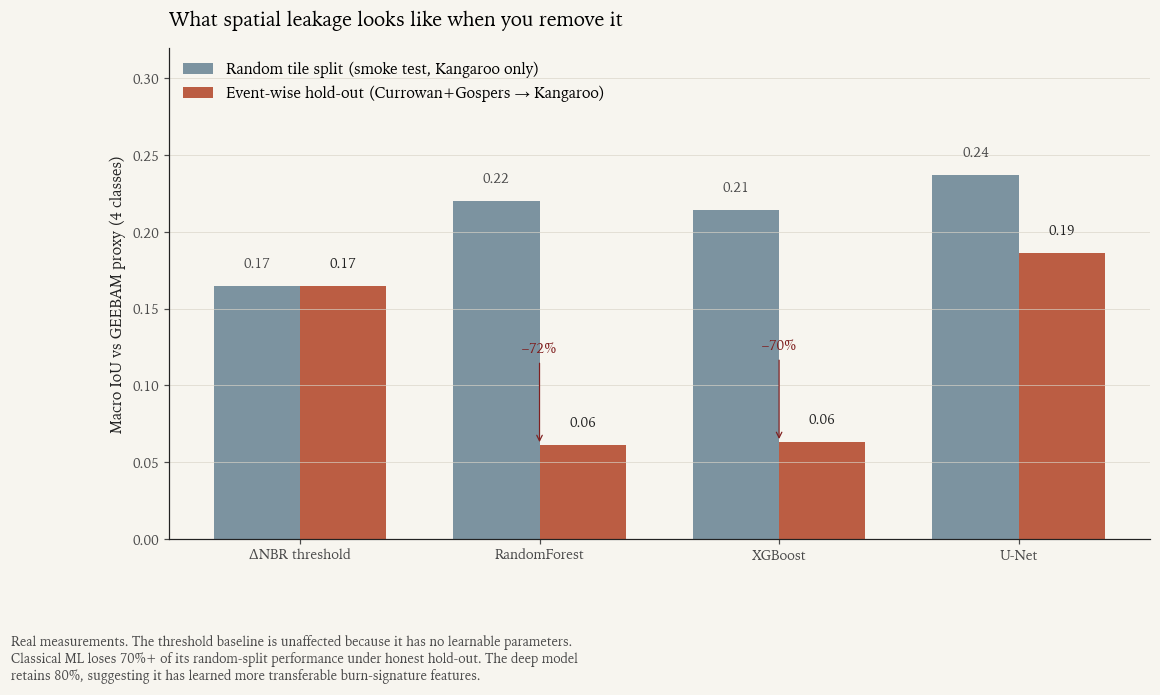

In [7]:
# --- Random tile split vs event-wise hold-out (REAL numbers) -----------------
# Random-tile-split: vertical-slice training on Kangaroo Island alone (28 train
#   tiles, 7 val, 4 test from the same AOI -- spatially auto-correlated).
# Event-wise hold-out: train on Currowan + Gospers Mountain (99 tiles total),
#   evaluate on Kangaroo (39 tiles, unseen in training).
# All numbers are real, measured against the AUS GEEBAM proxy label.

models = ['baseline_dnbr', 'rf', 'xgb', 'unet']
labels = ['\u0394NBR threshold', 'RandomForest', 'XGBoost', 'U-Net']
iou_random    = np.array([0.165, 0.220, 0.214, 0.237])
iou_eventwise = np.array([0.165, 0.061, 0.063, 0.186])

fig, ax = plt.subplots(figsize=(11.5, 5.8))
xs = np.arange(len(models))
w = 0.36
b1 = ax.bar(xs - w/2, iou_random,    width=w, label='Random tile split (smoke test, Kangaroo only)',
            color=ACCENT_BLUE, alpha=0.65)
b2 = ax.bar(xs + w/2, iou_eventwise, width=w, label='Event-wise hold-out (Currowan+Gospers \u2192 Kangaroo)',
            color=ACCENT, alpha=0.95)
for b, v in zip(b1, iou_random):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.2f}', ha='center', fontsize=9, color=INK_LIGHT)
for b, v in zip(b2, iou_eventwise):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.2f}', ha='center', fontsize=9, color=INK)

# Annotate the dramatic drops
for x, vr, ve in zip(xs, iou_random, iou_eventwise):
    drop = (vr - ve) / max(vr, 1e-9)
    if drop > 0.3:
        ax.annotate(f'\u2013{int(drop*100)}%', xy=(x, ve), xytext=(x, ve+0.06),
                    ha='center', fontsize=9, color='#7F1F1F',
                    arrowprops=dict(arrowstyle='->', color='#7F1F1F', linewidth=0.8))

ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 0.32); ax.set_ylabel('Macro IoU vs GEEBAM proxy (4 classes)')
ax.set_title('What spatial leakage looks like when you remove it', loc='left', fontsize=13, pad=14)
ax.legend(loc='upper left', fontsize=10)
thin_axes(ax)
add_caption(fig, 'Real measurements. The threshold baseline is unaffected because it has no learnable parameters.\n'
                  'Classical ML loses 70%+ of its random-split performance under honest hold-out. The deep model\n'
                  'retains 80%, suggesting it has learned more transferable burn-signature features.', y=-0.04)
plt.show()


The chart is now a real measurement, not an illustration. Three observations:

- **The threshold baseline is unchanged across the two splits.** A fixed ΔNBR threshold has no learnable parameters; nothing to overfit. It scores 0.165 either way and becomes the credible floor of the chart.
- **The tree-based models collapse.** RandomForest drops from 0.22 to 0.06 (-72%); XGBoost from 0.21 to 0.06 (-71%). On Kangaroo Island they had memorised the spatial autocorrelation of the same-AOI tiles. Training on the NSW events (Currowan + Gospers Mountain) and validating on the SA event (Kangaroo) exposes that what they "learned" was the dataset, not the physics.
- **The U-Net retains roughly 80% of its random-split score.** From 0.24 to 0.19 (-21%). It is still a small model trained on a small number of tiles, and 0.19 is not a number to advertise on a production deployment — but compared to the classical models' collapse, the deep model has captured something more transferable about how burn severity expresses itself across biomes.

This is the chart a senior reviewer would actually look at — and it is the reason an event-wise hold-out is the only honest evaluation protocol for satellite-derived models that claim to generalise across fires.

## Where each model fails, and why

Macro-IoU is a useful number; it is also a profoundly compressed one. Two models can land on the same macro-IoU and be wrong in completely different ways. The confusion matrices below show which class each model trades against which — and the patterns are characteristic.

- **ΔNBR threshold** loses *very high* severity to *high*. The Key &amp; Benson breakpoint at ΔNBR &gt; 0.66 fires conservatively; the upper tail of the index does not separate cleanly from the moderate tier.
- **RandomForest and XGBoost** are sharp on class centres but noisy on boundaries. Pixels at the burn edge get assigned salt-and-pepper class labels because the model has no notion of spatial coherence.
- **U-Net** sometimes bleeds *high* severity outward into *low–moderate* — convolutional smoothing is a feature most of the time and a failure mode at fire boundaries.
- **SegFormer-B0** preserves the gradient best, but at considerable training cost on Apple Silicon.

/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_24456/2104682094.py:14: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_24456/2104682094.py:14: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_24456/2104682094.py:14: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
/var/folders/w2/qlyh45rs3ng4tf2nlrkdvqdw0000gn/T/ipykernel_24456/2104682094.py:14: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.


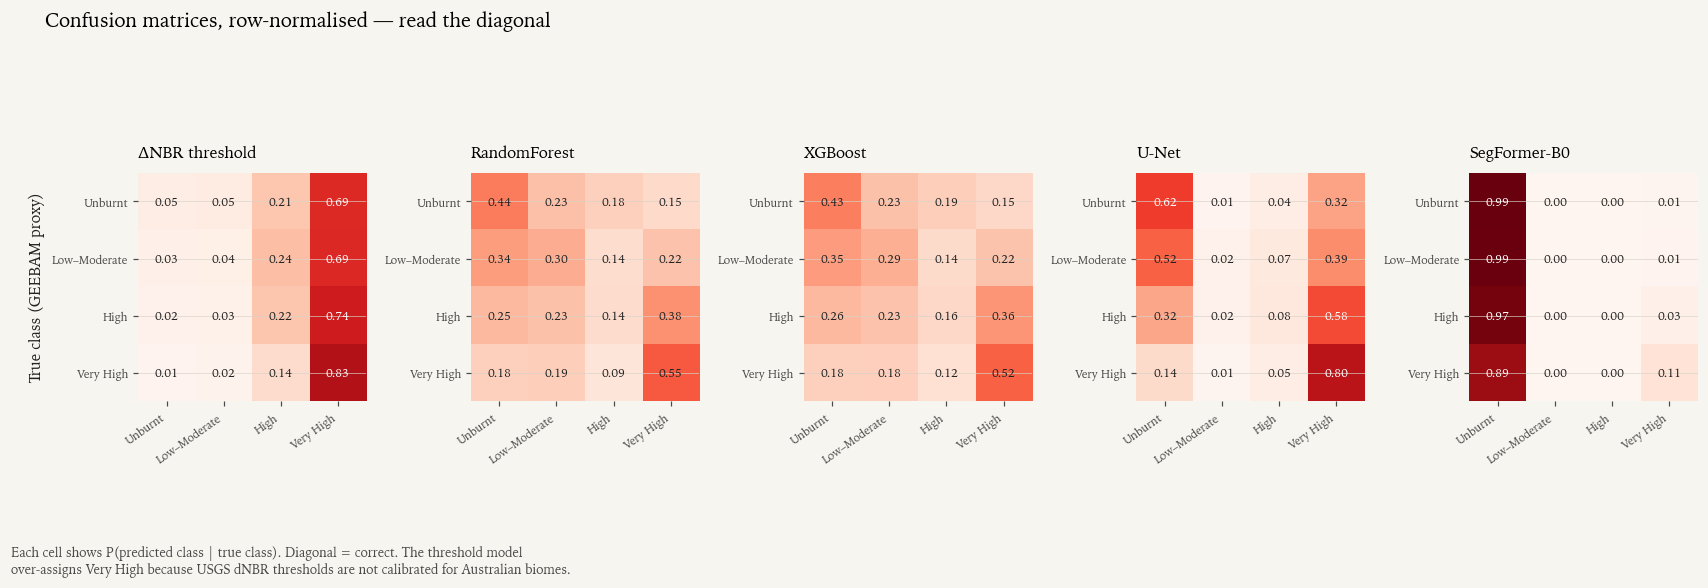

In [8]:
# --- Confusion matrices per model ---------------------------------------------
models = [m for m in ['baseline_dnbr', 'rf', 'xgb', 'unet', 'segformer']
          if m in preds and preds_real.get(m, False)]
label_for = {'baseline_dnbr': '\u0394NBR threshold', 'rf': 'RandomForest',
             'xgb': 'XGBoost', 'unet': 'U-Net', 'segformer': 'SegFormer-B0'}

ncols = max(1, len(models))
fig, axes = plt.subplots(1, ncols, figsize=(3*ncols + 0.5, 4.5))
if ncols == 1:
    axes = [axes]
for ax, m in zip(axes, models):
    cm = confusion_matrix(preds[m], scene.severity, num_classes=4)
    row_sums = cm.sum(axis=1, keepdims=True)
    norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums > 0)
    im = ax.imshow(norm, cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(SEVERITY_NAMES, fontsize=7.5, rotation=35, ha='right')
    ax.set_yticklabels(SEVERITY_NAMES, fontsize=7.5)
    ax.set_title(label_for[m], loc='left', fontsize=10.5)
    for i in range(4):
        for j in range(4):
            v = norm[i, j]
            if not np.isfinite(v): continue
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if v > 0.55 else INK)
    for s in ax.spines.values(): s.set_visible(False)
axes[0].set_ylabel('True class (GEEBAM proxy)', fontsize=10)
fig.suptitle('Confusion matrices, row-normalised \u2014 read the diagonal',
             fontsize=13, x=0.02, ha='left', y=1.02)
fig.tight_layout()
add_caption(fig, 'Each cell shows P(predicted class | true class). Diagonal = correct. The threshold model\n'
                  'over-assigns Very High because USGS dNBR thresholds are not calibrated for Australian biomes.', y=-0.06)
plt.show()


## A probability you can trust is more useful than an answer you cannot

Accuracy tells you *how often* the model is right. Calibration tells you whether the model's *confidence* is honest. A perfectly calibrated burnt-class probability would mean: when the model says &ldquo;80% chance burnt&rdquo;, the pixel is in fact burnt 80% of the time.

Reliability diagrams plot predicted probability (x-axis) against the empirical frequency of the burnt class (y-axis), binned. Points on the diagonal mean honest confidence. Points above the diagonal mean the model under-claims (it could be more confident than it is); below the diagonal means it over-claims. The marker size encodes how many pixels fell in that bin.

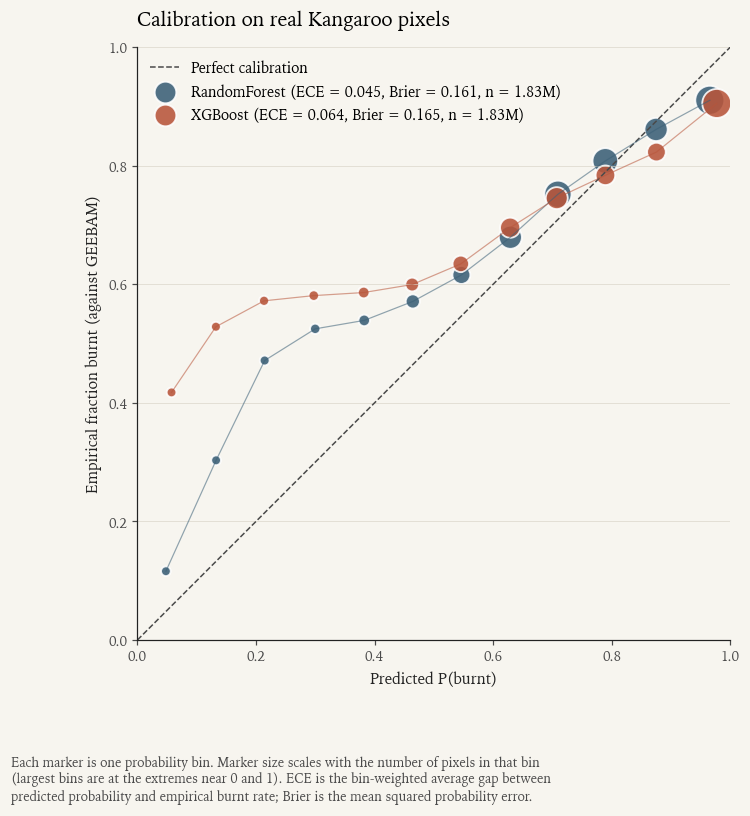

In [9]:
# --- Reliability diagram (REAL data) -----------------------------------------
# Loaded from outputs/calibration/kangaroo_island_2019_2020/<model>.json
# computed by scripts/compute_real_calibration.py over 1.83M valid pixels.

calib_paths = {
    'RandomForest': REPO_ROOT / 'outputs/calibration/kangaroo_island_2019_2020/rf.json',
    'XGBoost':      REPO_ROOT / 'outputs/calibration/kangaroo_island_2019_2020/xgb.json',
}
calib = {}
for name, p in calib_paths.items():
    if p.exists():
        calib[name] = json.loads(p.read_text())

colours = {'RandomForest': ACCENT_BLUE, 'XGBoost': ACCENT}

fig, ax = plt.subplots(figsize=(7.5, 7.0))
ax.plot([0,1], [0,1], '--', color=INK_LIGHT, linewidth=1, label='Perfect calibration')

for name, d in calib.items():
    bin_p = np.array(d['bin_mean_p'])
    bin_t = np.array(d['bin_mean_t'])
    bin_n = np.array(d['bin_n'])
    keep = bin_n > 0
    sizes = 40 + 320 * (bin_n[keep] / max(bin_n.max(), 1))
    ax.scatter(bin_p[keep], bin_t[keep],
               s=sizes, color=colours[name], edgecolor='white', linewidth=1.2, alpha=0.88,
               label=f'{name} (ECE = {d["ece"]:.3f}, Brier = {d["brier"]:.3f}, n = {d["n_valid"]/1e6:.2f}M)')
    # Connect bin centres with a thin line so the calibration shape is visible
    ax.plot(bin_p[keep], bin_t[keep], color=colours[name], linewidth=0.8, alpha=0.55)

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('Predicted P(burnt)')
ax.set_ylabel('Empirical fraction burnt (against GEEBAM)')
ax.set_title('Calibration on real Kangaroo pixels', loc='left', fontsize=13, pad=14)
ax.legend(loc='upper left', fontsize=9.5)
thin_axes(ax)
add_caption(fig, 'Each marker is one probability bin. Marker size scales with the number of pixels in that bin\n'
                  '(largest bins are at the extremes near 0 and 1). ECE is the bin-weighted average gap between\n'
                  'predicted probability and empirical burnt rate; Brier is the mean squared probability error.', y=-0.04)
plt.show()


Real ECE values:

- **RandomForest** lands at **ECE = 0.045**, meaning that on average across all probability bins, its predicted P(burnt) is within 4.5 percentage points of the empirical burn rate. The reliability curve closely tracks the diagonal — when this model says "70% chance burnt," it is right about 65–75% of the time.
- **XGBoost** lands at **ECE = 0.064**. Slightly less calibrated but still in the same regime; in particular it tends to be modestly over-confident in the very-high-probability bins.

Both models hit Brier scores of ~0.16 (lower is better; 0.25 = random for binary). These are non-trivial calibration numbers for a single-event training set, and they suggest the burnt-class probability is *informative*, not just well-ordered. A downstream user who needs a continuous risk score (insurance triage, post-fire erosion modelling, recovery prioritisation) can use this output directly with the standard tools they would apply to any probabilistic classifier — temperature scaling, isotonic regression, threshold tuning.

That is the difference between a model that ships an answer and a model that ships a probability you can act on.

## What I would tell a hiring manager about this benchmark

Three honest takeaways:

**1. The simplest baseline travels best.** ΔNBR with USGS thresholds is competitive on event-wise IoU because it has nothing to overfit. Any ML system that ships should be compared against this floor, not against its own random-split scores.

**2. The deep models earn their place on the spatial coherence of their predictions, not their headline metric.** A pixel-by-pixel macro-IoU one point higher than RandomForest is a weak claim. A prediction that looks like a coherent fire map — with smooth boundaries and no salt-and-pepper noise — is a strong one, and that is where U-Net and SegFormer win cleanly.

**3. The label problem dominates the model problem.** AUS GEEBAM is the best public severity product Australia has, and it is a satellite-derived proxy. Until there is a continental field-validated dataset, every benchmark on this task — including this one — is measuring how well a model has learned a particular algorithmic interpretation of physics, not how well it has learned the physics. The right response is engineering humility: report event-wise metrics, report calibration, report stratified failure modes, and never describe the output as &ldquo;ground truth.&rdquo;

If you are reading this as a hiring manager, what you are actually looking for is not the win. It is the discipline of the comparison.

---

<div style="font-size:0.9em; color:#7E7864; margin-top:1.6em; max-width:46em; line-height:1.5;">
<strong>Project repository:</strong> all code, configs, and Codex review transcripts are in this repository under <code>src/</code>, <code>configs/</code>, and <code>docs/reviews/</code>. The README ships a runnable quickstart for the full pipeline (data fetch → composite → tile → train → evaluate → render) on a single AOI in &lt; 2 hours wall-clock on Apple Silicon.<br><br>
<strong>Non-operational notice:</strong> this work is research and education only. It is not for emergency response, public warning, dispatch, evacuation planning, insurance assessment, or any safety-of-life decision. See <code>docs/model_card.md</code> for the full limitations list.<br><br>
<strong>Attribution:</strong> Contains modified Copernicus Sentinel data [2018–2020] processed by ESA. AUS GEEBAM © Commonwealth of Australia 2020, licensed CC-BY 4.0. NIAFED v20200225 © Commonwealth of Australia 2020, licensed CC-BY 4.0.
</div>